# Perceptron

the perceptron is the simplest neural net, just one neuron. it takes the inputs, weights them, adds a bias, and fires 1 or 0. lets see what it can do and where it breaks.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## what it is

output = step(w·x + b). the step fires 1 if the weighted sum is >= 0, else 0. thats the whole neuron.

In [2]:
def step(z):
    return np.where(z >= 0, 1, 0)

def predict(X, w, b):
    return step(X @ w + b)

## forward pass by hand

pick weights w=[1,1], b=-0.5 and push the 4 OR inputs through. the maths itself gives the OR answer.

In [3]:
w = np.array([1.0, 1.0])
b = -0.5

for x in [[0, 0], [0, 1], [1, 0], [1, 1]]:
    z = np.dot(x, w) + b
    print(x, " z =", round(z, 1), " output =", int(z >= 0))

[0, 0]  z = -0.5  output = 0
[0, 1]  z = 0.5  output = 1
[1, 0]  z = 0.5  output = 1
[1, 1]  z = 1.5  output = 1


## the learning rule

instead of guessing the weights we train them. for each point, w = w + lr*(y - pred)*x. right answer, no change. wrong, nudge towards it. repeat for a few epochs.

In [4]:
def train_perceptron(X, y, lr=0.1, epochs=20):
    w = np.zeros(X.shape[1])
    b = 0.0
    errors = []                       # mistakes per epoch
    for ep in range(epochs):
        e = 0
        for i in range(len(X)):
            pred = step(X[i] @ w + b)
            update = lr * (y[i] - pred)
            w = w + update * X[i]
            b = b + update
            e += int(update != 0)
        errors.append(e)
    return w, b, errors

## logical OR

OR is linearly separable, one straight line can split the 1s from the 0s.

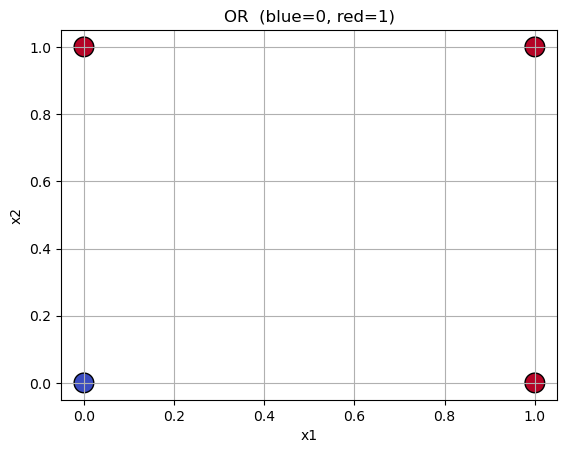

In [5]:
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_or = np.array([0, 1, 1, 1])

plt.scatter(X[:, 0], X[:, 1], c=y_or, cmap='coolwarm', s=200, edgecolors='k')
plt.title("OR  (blue=0, red=1)")
plt.xlabel("x1"); plt.ylabel("x2"); plt.grid(True); plt.show()

In [6]:
w, b, errors = train_perceptron(X, y_or)
print("weights:", w, " bias:", round(b, 2))
print("accuracy:", (predict(X, w, b) == y_or).mean())

weights: [0.1 0.1]  bias: -0.1
accuracy: 1.0


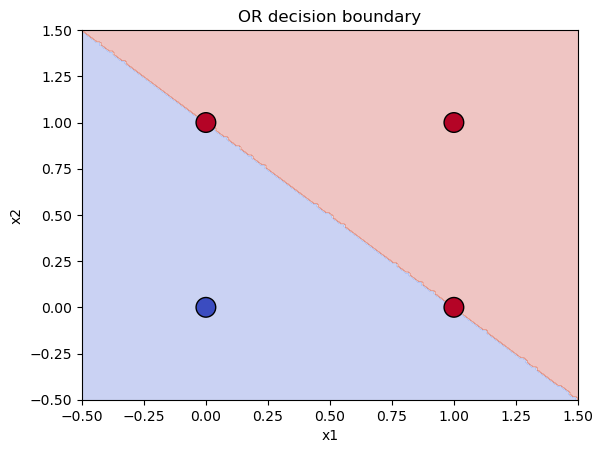

In [7]:
def plot_boundary(predict_fn, X, y, title):
    xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
    Z = predict_fn(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=200, edgecolors='k')
    plt.title(title); plt.xlabel("x1"); plt.ylabel("x2"); plt.show()

plot_boundary(lambda G: predict(G, w, b), X, y_or, "OR decision boundary")

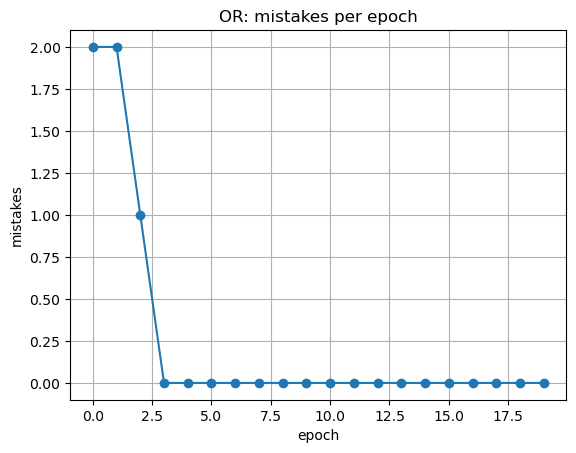

In [8]:
# the mistakes drop to 0, that means it converged
plt.plot(errors, marker='o')
plt.title("OR: mistakes per epoch")
plt.xlabel("epoch"); plt.ylabel("mistakes"); plt.grid(True); plt.show()

## logical AND

same story, AND is also linearly separable so the perceptron handles it fine.

accuracy: 1.0


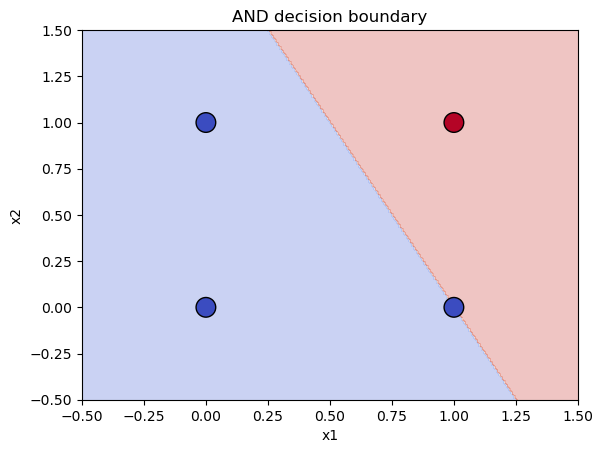

In [9]:
y_and = np.array([0, 0, 0, 1])
w2, b2, errors2 = train_perceptron(X, y_and)
print("accuracy:", (predict(X, w2, b2) == y_and).mean())

plot_boundary(lambda G: predict(G, w2, b2), X, y_and, "AND decision boundary")

## XOR

now the famous one. the 1s sit on one diagonal and the 0s on the other.

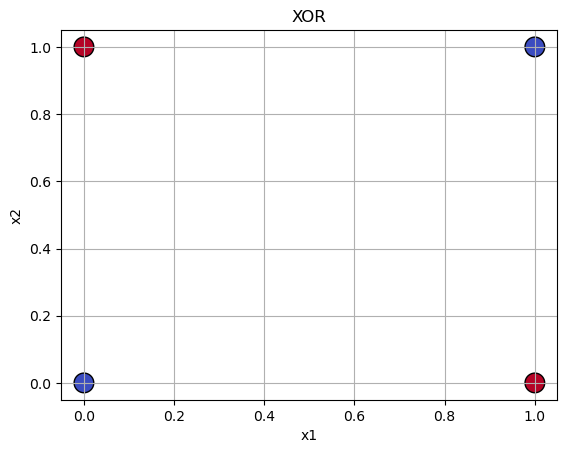

In [10]:
y_xor = np.array([0, 1, 1, 0])

plt.scatter(X[:, 0], X[:, 1], c=y_xor, cmap='coolwarm', s=200, edgecolors='k')
plt.title("XOR")
plt.xlabel("x1"); plt.ylabel("x2"); plt.grid(True); plt.show()

accuracy: 0.5


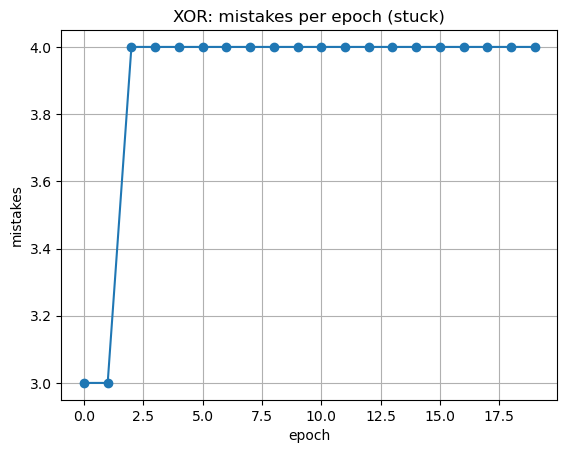

In [11]:
w3, b3, errors3 = train_perceptron(X, y_xor, epochs=20)
print("accuracy:", (predict(X, w3, b3) == y_xor).mean())

# it gets stuck, the mistakes never reach 0
plt.plot(errors3, marker='o')
plt.title("XOR: mistakes per epoch (stuck)")
plt.xlabel("epoch"); plt.ylabel("mistakes"); plt.grid(True); plt.show()

In [12]:
# which ones is it getting wrong
print("pred  :", predict(X, w3, b3))
print("actual:", y_xor)

pred  : [1 1 0 0]
actual: [0 1 1 0]


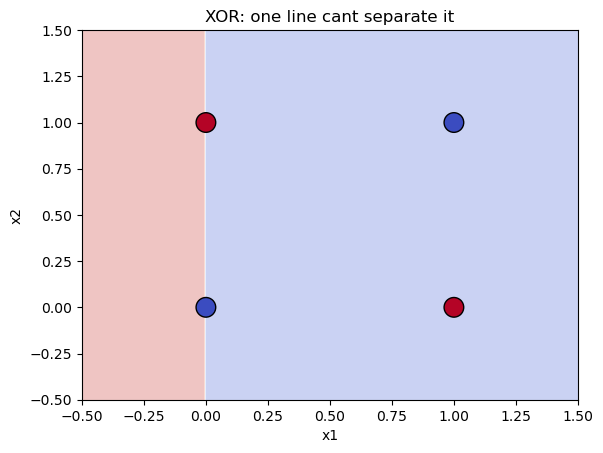

In [13]:
plot_boundary(lambda G: predict(G, w3, b3), X, y_xor, "XOR: one line cant separate it")

## why it fails

the perceptron only ever draws ONE straight line. XOR would need two, no single line puts both red points on one side and both blue on the other. so a perceptron only works on **linearly separable** data, like OR and AND.

## multi layer perceptron

the fix is to stack neurons into layers. a hidden layer lets the net bend the boundary into nonlinear shapes. heres sklearn's MLP solving XOR, just as a preview.

MLP accuracy on XOR: 1.0


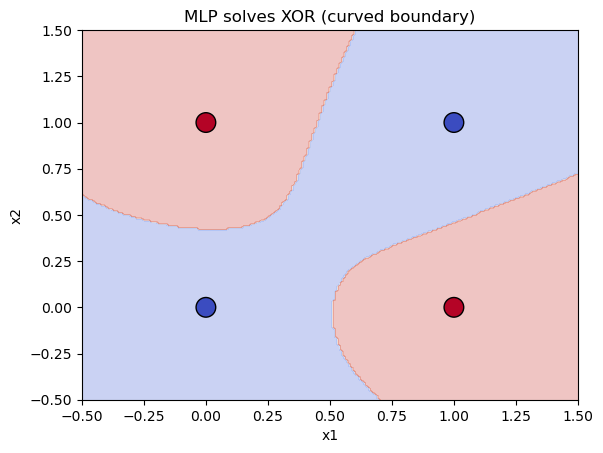

In [14]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(8,), activation='tanh', max_iter=5000, random_state=1)
mlp.fit(X, y_xor)
print("MLP accuracy on XOR:", (mlp.predict(X) == y_xor).mean())

plot_boundary(mlp.predict, X, y_xor, "MLP solves XOR (curved boundary)")

so one perceptron is just one straight line, only good for linear problems like OR and AND. add a hidden layer and it bends enough to solve XOR. next i build that MLP from scratch.